# CS9647 Project: Classifying Crisis Severity in Mental Health Social Media Posts Using Transformer-Based Language Models

### Dataset:
https://www.kaggle.com/datasets/entenam/reddit-mental-health-dataset

### Project Goal:
Presents a pipeline for classifying Reddit posts
into three crisis severity levels: high risk, medium risk, and low risk.

### Steps
1. Dataset set up
2. Data preprocess and cleaning
3. Build a TF-IDF baseline
4. Train BERT and RoBERTa models
5. Compare results and inspect model errors



## Dataset set up




In [1]:
# Kaggle setup
!pip install kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
# download dataset
!kaggle datasets download -d entenam/reddit-mental-health-dataset -q
!unzip -q reddit-mental-health-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/entenam/reddit-mental-health-dataset
License(s): CC0-1.0


In [3]:
import os

os.listdir("Original Reddit Data/raw data/2020/Jan 20")

['depjan20 .csv',
 'anxijan20.csv',
 'Mhjan20.csv',
 'SWjan20.csv',
 'lonejan20.csv']

In [4]:
import pandas as pd

df = pd.read_csv("Original Reddit Data/raw data/2020/Jan 20/SWjan20.csv")
print(df.columns.tolist())
df.head(5)

['Unnamed: 0', 'author', 'created_utc', 'score', 'selftext', 'subreddit', 'title', 'timestamp']


,Unnamed: 0,author,created_utc,score,selftext,subreddit,title,timestamp
0,0,According_Mistake,1580475258,1,\n\nI know it probably sounds daft but the do...,SuicideWatch,Can I (17 F) have my gut surgically removed an...,2020-01-31 23:54:18
1,1,matt_the_jet,1580475059,1,\nJust looking for some answers,SuicideWatch,Fastest way to kill your self or easiest way to,2020-01-31 23:50:59
2,2,Tripledickmafia,1580474409,1,"Whether it be a heart attack, anurysm, or what...",SuicideWatch,Kill me kill me kill me kill me,2020-01-31 23:40:09
3,3,madbutt,1580474326,1,I was born in a small rural town in a third wo...,SuicideWatch,My no life story,2020-01-31 23:38:46
4,4,panaphonic8,1580473945,1,[removed],SuicideWatch,Does anyone need help right now?,2020-01-31 23:32:25


# Data Preprocessing

### Dataset Source
- Reddit Mental Health Dataset (RMHD) from Kaggle
- Focused on year 2020 due to increased mental health activity during COVID-19

### Data Processing Steps
1. Data Loading
- Loaded raw Reddit data from monthly CSV files (Jan–Dec 2020)
- Included 5 mental health subreddits, proxy label:
  - SuicideWatch → high risk
  - depression, anxiety → medium risk
  - lonely, mentalhealth → low risk
2. Label Assignment
- Assigned severity labels based on filename prefixes
- Used case-insensitive matching to ensure all files were correctly included

3. Main Preprocessing
- Combined title and body into one text field
- Removing URLs
- Removing [removed] and [deleted]
- Removing usernames and mentions
- Converting text to lowercase
- Filtered out posts with length < 20 characters
- Removed duplicate posts
- Ensured no empty text entries




Because the original dataset is imbalanced (uneven distribution), so a balanced dataset was created by downsampling each class to the size of the smallest class.

In the end, both a **full cleaned dataset** and a **balanced dataset** are saved.


In [19]:
import os
import pandas as pd
import numpy as np
import re

import random
import torch

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# config
BASE_PATH = "Original Reddit Data/raw data/2020"
FULL_OUTPUT_FILE = "rmhd_2020_processed_full.csv"
BALANCED_OUTPUT_FILE = "rmhd_2020_processed_balanced.csv"
MIN_TEXT_LEN = 20


# filename prefix -> severity label
LABEL_MAP = {
    "SW": "high",
    "dep": "medium",
    "anxi": "medium",
    "lone": "low",
    "Mh": "low"
}

# manual month order because folder names are inconsistent
MONTH_ORDER = [
    "Jan 20", "Feb20", "Mar 20", "Apr 20", "May 20", "June 20",
    "Jul 20", "Aug 20", "Sep 20", "Oct 20", "Nov 20", "Dec 20"
]

def clean_text(text: str) -> str:
    """Clean Reddit post text while keeping enough signal for NLP."""
    if pd.isna(text):
        return ""

    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text) # remove URLs
    text = re.sub(r"\[removed\]|\[deleted\]", "", text) # remove Reddit placeholders
    text = re.sub(r"/u/\w+|u/\w+|@\w+", "", text) # remove usernames / mentions
    text = re.sub(r"\s+", " ", text).strip() # normalize whitespace
    text = text.lower()

    return text

def get_label_from_filename(filename):
    filename_lower = filename.lower().strip()

    if filename_lower.startswith("sw"):
        return "high"
    elif filename_lower.startswith("dep"):
        return "medium"
    elif filename_lower.startswith("anx"):  # add anx
        return "medium"
    elif filename_lower.startswith("anxiety"):
        return "medium"
    elif filename_lower.startswith("lone"):
        return "low"
    elif filename_lower.startswith("mh") or filename_lower.startswith("mhe"):
        return "low"
    else:
        return None

def detect_text_columns(df: pd.DataFrame, filename: str) -> tuple[str, str]:
    """Strictly detect title/body columns. Fail loudly if unexpected."""
    cols = df.columns.tolist()

    if "title" in cols and "selftext" in cols:
        return "title", "selftext"

    if "title" in cols and "body" in cols:
        return "title", "body"

    if "title" in cols and "text" in cols:
        return "title", "text"

    raise ValueError(f"Unexpected columns in {filename}: {cols}")

frames = []

for month in MONTH_ORDER:
    month_path = os.path.join(BASE_PATH, month)

    if not os.path.isdir(month_path):
        print(f"Skipping missing folder: {month}")
        continue

    print(f"\nProcessing: {month}")

    for file in sorted(os.listdir(month_path)): # fixed here
          if not file.endswith(".csv"):
              continue

          label = get_label_from_filename(file)
          if label is None:
              print(f"  Skipping unrecognized file: {file}")
              continue

          file_path = os.path.join(month_path, file)

          try:
              df = pd.read_csv(file_path)
          except Exception as e:
              print(f"  Skipping problematic file: {file} — {e}")
              continue

          try:
              title_col, body_col = detect_text_columns(df, file)
          except ValueError as e:
              print(f"  {e}")
              continue


          # combine title + body as one text field
          df["title_clean"] = df[title_col].fillna("").astype(str)
          df["body_clean"] = df[body_col].fillna("").astype(str)

          df["text"] = (df["title_clean"] + " " + df["body_clean"]).apply(clean_text)

          # drop rows thats too short
          before_len_filter = len(df)
          df = df[df["text"].str.len() >= MIN_TEXT_LEN].copy()
          dropped_short = before_len_filter - len(df)

          df["label"] = label
          frames.append(df[["text", "label"]])

          print(f"  {file} -> {label} | kept: {len(df)} | dropped short: {dropped_short}")

if not frames:
    raise ValueError("No data was processed. Check paths, filenames, and column names.")

# combine all processed rows
full_df = pd.concat(frames, ignore_index=True)

# remove duplicate posts
before_dedup = len(full_df)
full_df = full_df.drop_duplicates(subset=["text"]).reset_index(drop=True)
dropped_duplicates = before_dedup - len(full_df)

# add text length stats
full_df["text_len"] = full_df["text"].str.len()

# full dataset summary
print("\n=== FULL DATASET SUMMARY ===")
print(f"Total posts after cleaning: {len(full_df)}")
print(f"Duplicates removed: {dropped_duplicates}")
print(f"Empty text rows: {(full_df['text'].str.len() == 0).sum()}\n")

print("Class distribution:")
print(full_df["label"].value_counts(), "\n")

print("Text length stats by class:")
print(full_df.groupby("label")["text_len"].describe()[["count", "mean", "std", "min", "max"]])

# save full cleaned dataset
full_df.to_csv(FULL_OUTPUT_FILE, index=False)
print(f"\nSaved full cleaned dataset to: {FULL_OUTPUT_FILE}")

# balanced dataset summary
min_class_size = full_df["label"].value_counts().min()
print(f"\nSmallest class size: {min_class_size}")
print("Creating balanced dataset by downsampling each class...")

balanced_df = (
    full_df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=min_class_size, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print("\n=== BALANCED DATASET SUMMARY ===")
print(f"Total posts: {len(balanced_df)}\n")

print("Balanced class distribution:")
print(balanced_df["label"].value_counts(), "\n")

print("Balanced text length stats by class:")
print(balanced_df.groupby("label")["text_len"].describe()[["count", "mean", "std", "min", "max"]])

balanced_df.to_csv(BALANCED_OUTPUT_FILE, index=False)
print(f"\nSaved balanced dataset to: {BALANCED_OUTPUT_FILE}")


Processing: Jan 20
  Mhjan20.csv -> low | kept: 4674 | dropped short: 26
  SWjan20.csv -> high | kept: 8005 | dropped short: 156
  anxijan20.csv -> medium | kept: 5714 | dropped short: 36
  depjan20 .csv -> medium | kept: 17212 | dropped short: 304
  lonejan20.csv -> low | kept: 3021 | dropped short: 40

Processing: Feb20
  Mhfeb20.csv -> low | kept: 4485 | dropped short: 20
  anxifeb20.csv -> medium | kept: 5399 | dropped short: 27
  depfeb20.csv -> medium | kept: 16162 | dropped short: 238
  lonefeb20.csv -> low | kept: 3149 | dropped short: 40
  swfeb20.csv -> high | kept: 8400 | dropped short: 122

Processing: Mar 20
  Mhmar20.csv -> low | kept: 4674 | dropped short: 26
  anximar20.csv -> medium | kept: 5643 | dropped short: 24
  depmar20.csv -> medium | kept: 14946 | dropped short: 253
  lonemar20.csv -> low | kept: 3176 | dropped short: 53
  swmar20.csv -> high | kept: 8590 | dropped short: 142

Processing: Apr 20
  Mhapr20.csv -> low | kept: 4997 | dropped short: 37
  Swapr20.c

/tmp/ipykernel_7012/2377266500.py:178: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_class_size, random_state=RANDOM_STATE))


           count        mean          std   min      max
label                                                   
high    109023.0  777.305679  1115.945106  20.0  39511.0
low     109023.0  960.337534  1240.717106  20.0  39772.0
medium  109023.0  846.245499  1056.592240  20.0  31864.0

Saved balanced dataset to: rmhd_2020_processed_balanced.csv


**NOTE: the numbers change slighlty each time we run the codes above, but it's within a normal range, the data and conclusions will not vary widely.**
### Preprocessing Observations
- Dataset is imbalanced, with more **medium-risk** posts
- Low-risk posts tend to be longer on average
- Balanced dataset is used to fix this

### Notes
- Labels are assigned using subreddit as a proxy, not manual annotation
- Data is restricted to 2020 (COVID period), which may affect generalizability
- The balanced dataset (rmhd_2020_processed_balanced.csv) will be used for baseline modeling


## Baseline Model: TF-IDF + Logistic Regression

Traditional NLP before moving to transformers

### Goal
Predict mental health severity level:
- low
- medium
- high

### Method
- Text representation: **TF-IDF**
- Classifier: **Logistic Regression** and **Multinomial Naive Bayes**
- Evaluation: **precision, recall, F1-score, and confusion matrix**

This baseline will be used as a reference to see if BERT OR RoBERTa actually improves.



In [20]:
import pandas as pd

# load balanced dataset
df = pd.read_csv("rmhd_2020_processed_balanced.csv")

print(df.shape)
print(df["label"].value_counts())
df.head()

(327069, 3)
label
high      109023
low       109023
medium    109023
Name: count, dtype: int64


,text,label,text_len
0,suicide fast vs suicide slow i guess i’ve chos...,high,76
1,everything that has kept me going is disappear...,high,50
2,i think i’m finally dying i was gonna wait unt...,high,477
3,not sure what to do anymore. i have recently f...,high,1274
4,i’m irredeemable im a coward and i have nothin...,high,789


Because the balanced dataset is large, we adapt a smaller subset to try here.

## Phase 1: Baseline Modelling
Sample:
- 5,000 posts per class
- Total: 15,000 posts

### Models
- Logistic Regression
- Multinomial Naive Bayes

Train on a 70/15/15 Split. The best baseline model is selected using **macro F1-score** on the validation set.

Working sample: 15000 rows
label
medium    5000
low       5000
high      5000
Name: count, dtype: int64

Train: 10500 | Val: 2250 | Test: 2250
Vocabulary size: 50,000

──────────────────────────────────────────────────
Logistic Regression — Validation Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        high      0.654     0.696     0.674       750
         low      0.628     0.628     0.628       750
      medium      0.541     0.507     0.523       750

    accuracy                          0.610      2250
   macro avg      0.608     0.610     0.609      2250
weighted avg      0.608     0.610     0.609      2250


──────────────────────────────────────────────────
Naive Bayes — Validation Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        high      0.631     0.711     0.668       750
         low      0.615     0.616     0.616       750
      med

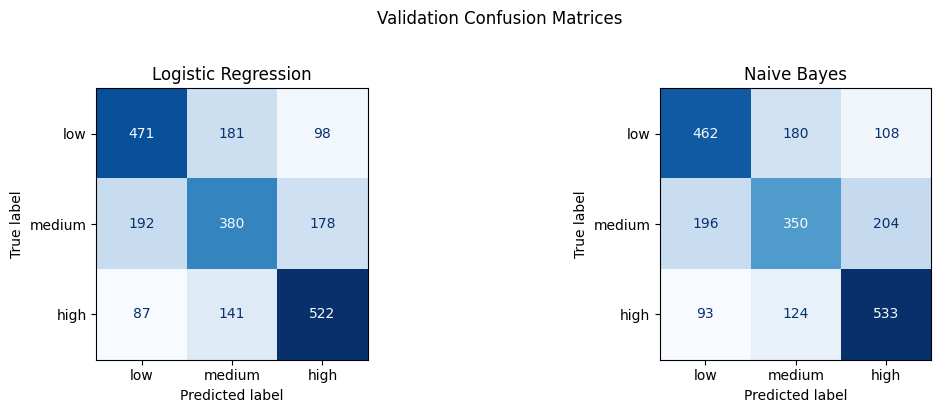


Best model: Logistic Regression
Test Set Results
              precision    recall  f1-score   support

        high      0.703     0.689     0.696       750
         low      0.625     0.685     0.654       750
      medium      0.599     0.553     0.575       750

    accuracy                          0.643      2250
   macro avg      0.643     0.643     0.642      2250
weighted avg      0.643     0.643     0.642      2250



In [30]:
# Phase 1: TF-IDF Baseline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


RANDOM_STATE = 42
SAMPLE_PER_CLASS = 5000


# 1. Load + create smaller modelling sample
df = pd.read_csv("rmhd_2020_processed_balanced.csv")

sampled_parts = []
for label, group in df.groupby("label"):
    sampled_parts.append(group.sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_STATE))

sample_df = (
    pd.concat(sampled_parts)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"Working sample: {len(sample_df)} rows")
print(sample_df["label"].value_counts())


# 2. Train / Val / Test Split (70/15/15)
X = sample_df["text"]
y = sample_df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# 3. Convert text into TF-IDF features
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    strip_accents="unicode",
)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)
X_test_vec  = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

# 4. Train and compare baseline models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": MultinomialNB(alpha=0.1),
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    val_preds = model.predict(X_val_vec)
    results[name] = val_preds

    print(f"\n{'─'*50}")
    print(f"{name} — Validation Results")
    print('─'*50)
    print(classification_report(y_val, val_preds, digits=3))


# 5. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels_order = ["low", "medium", "high"]

for ax, (name, preds) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, preds, labels=labels_order)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels_order)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Validation Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()


# 6. Select the best baseline using validation macro F1
best_name = max(
    results,
    key=lambda n: classification_report(
        y_val, results[n], output_dict=True
    )["macro avg"]["f1-score"]
)

best_model = models[best_name]

# 7. Final test evaluation for the best baseline
test_preds = best_model.predict(X_test_vec)

print(f"\n{'='*50}")
print(f"Best model: {best_name}")
print("Test Set Results")
print('='*50)

print(classification_report(y_test, test_preds, digits=3))

## Phase 2: BERT fine-tuning

Moving to a transformer model to test whether it improve performance.


### Setup
- Model: **bert-base-uncased**
- Max sequence length: **256**
- Balanced sample: **same 5,000 posts per class**
- Split: same **70/15/15** for train, validation, and test

Also compared training length and keep track of whether extra epochs (3) actually help or start to overfit


Working sample: 15000 rows
label
medium    5000
low       5000
high      5000
Name: count, dtype: int64

Train: 10500 | Val: 2250 | Test: 2250


Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.851433,0.798937,0.655556,0.650635
2,0.641273,0.799502,0.663111,0.660261


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


──────────────────────────────────────────────────
BERT — Validation Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

         low      0.694     0.641     0.667       750
      medium      0.608     0.559     0.582       750
        high      0.682     0.789     0.732       750

    accuracy                          0.663      2250
   macro avg      0.661     0.663     0.660      2250
weighted avg      0.661     0.663     0.660      2250



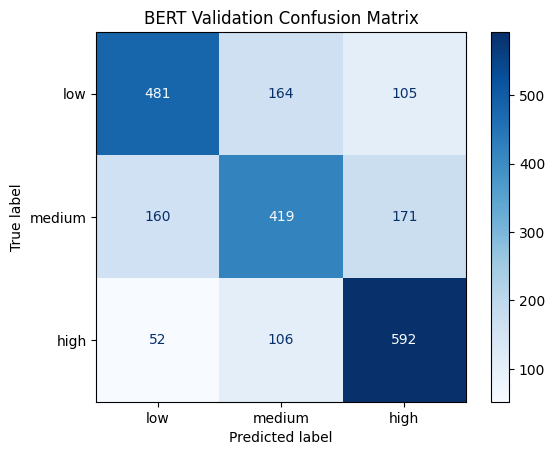


BERT — Test Results
              precision    recall  f1-score   support

         low      0.687     0.643     0.664       750
      medium      0.603     0.556     0.579       750
        high      0.700     0.800     0.747       750

    accuracy                          0.666      2250
   macro avg      0.663     0.666     0.663      2250
weighted avg      0.663     0.666     0.663      2250



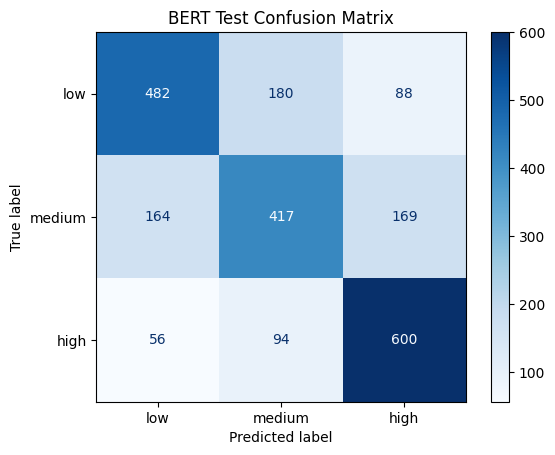

In [22]:
# Phase 2: BERT

!pip -q install transformers datasets accelerate evaluate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import evaluate

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)



RANDOM_STATE = 42
SAMPLE_PER_CLASS = 5000
MODEL_CHECKPOINT = "bert-base-uncased"
MAX_LENGTH = 256


# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Device:", device)
# if device == "cuda":
#   print("GPU:", torch.cuda.get_device_name(0))


# 1. Load + subsample
df = pd.read_csv("rmhd_2020_processed_balanced.csv")

sampled_parts = []
for label, group in df.groupby("label"):
    sampled_parts.append(group.sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_STATE))

sample_df = (
    pd.concat(sampled_parts)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"\nWorking sample: {len(sample_df)} rows")
print(sample_df["label"].value_counts())


# 2. Label mapping
label2id = {"low": 0, "medium": 1, "high": 2}
id2label = {0: "low", 1: "medium", 2: "high"}

sample_df["label_id"] = sample_df["label"].map(label2id)


# 3. Train / Val / Test Split (70/15/15)
X = sample_df["text"]
y = sample_df["label_id"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


# 4. Convert to Hugging Face dataset
train_df = pd.DataFrame({"text": X_train.tolist(), "label": y_train.tolist()})
val_df   = pd.DataFrame({"text": X_val.tolist(),   "label": y_val.tolist()})
test_df  = pd.DataFrame({"text": X_test.tolist(),  "label": y_test.tolist()})

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})


# 5. Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# 6. Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)
    f1_macro = f1_metric.compute(predictions=preds, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "f1_macro": f1_macro["f1"]
    }


# 7. Load model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


# 8. Training arguments
training_args = TrainingArguments(
    output_dir="./bert_rmhd_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)



# 9. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


# 10. Train
print("\nBERT training")
trainer.train()


# 11. Validation evaluation
val_outputs = trainer.predict(tokenized_dataset["validation"])
val_logits = val_outputs.predictions
val_preds = np.argmax(val_logits, axis=-1)
val_labels = np.array(tokenized_dataset["validation"]["label"])

print(f"\n{'─'*50}")
print("BERT — Validation Results")
print('─'*50)
print(classification_report(
    val_labels,
    val_preds,
    target_names=["low", "medium", "high"],
    digits=3
))


# 12. Validation confusion matrix
cm_val = confusion_matrix(val_labels, val_preds, labels=[0, 1, 2])
disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["low", "medium", "high"]
)

disp_val.plot(cmap="Blues")
plt.title("BERT Validation Confusion Matrix")
plt.show()


# 13. Test evaluation
test_outputs = trainer.predict(tokenized_dataset["test"])
test_logits = test_outputs.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_labels = np.array(tokenized_dataset["test"]["label"])

print(f"\n{'='*50}")
print("BERT — Test Results")
print('='*50)
print(classification_report(
    test_labels,
    test_preds,
    target_names=["low", "medium", "high"],
    digits=3
))


# 14. Test confusion matrix
cm_test = confusion_matrix(test_labels, test_preds, labels=[0, 1, 2])
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["low", "medium", "high"]
)

disp_test.plot(cmap="Blues")
plt.title("BERT Test Confusion Matrix")
plt.show()

In [23]:
# BERT 3-epoch comparison

!pip -q install transformers datasets accelerate evaluate

import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)


RANDOM_STATE = 42
SAMPLE_PER_CLASS = 5000
MODEL_CHECKPOINT = "bert-base-uncased"
MAX_LENGTH = 256


# 1. Load + subsample
df = pd.read_csv("rmhd_2020_processed_balanced.csv")

sampled_parts = []
for label, group in df.groupby("label"):
    sampled_parts.append(group.sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_STATE))

sample_df = (
    pd.concat(sampled_parts)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)


# 2. Label mapping
label2id = {"low": 0, "medium": 1, "high": 2}
id2label = {0: "low", 1: "medium", 2: "high"}

sample_df["label_id"] = sample_df["label"].map(label2id)


# 3. Train / Val / Test Split (70/15/15)
X = sample_df["text"]
y = sample_df["label_id"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)


# 4. Convert to Hugging Face dataset
train_df = pd.DataFrame({"text": X_train.tolist(), "label": y_train.tolist()})
val_df   = pd.DataFrame({"text": X_val.tolist(),   "label": y_val.tolist()})
test_df  = pd.DataFrame({"text": X_test.tolist(),  "label": y_test.tolist()})

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})


# 5. Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# 6. Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)
    f1_macro = f1_metric.compute(predictions=preds, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "f1_macro": f1_macro["f1"]
    }


# 7. Load model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


# 8. Training arguments
training_args = TrainingArguments(
    output_dir="./bert_rmhd_3epoch_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)


# 9. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


# 10. Train
trainer.train()


# 11. Test results
test_outputs = trainer.predict(tokenized_dataset["test"])
test_preds = np.argmax(test_outputs.predictions, axis=-1)
test_labels = np.array(tokenized_dataset["test"]["label"])

print("\nBERT (3 epochs) — Test Results")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["low", "medium", "high"],
    digits=3
))

Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


BERT (3 epochs) — Test Results
              precision    recall  f1-score   support

         low      0.730     0.587     0.650       750
      medium      0.572     0.617     0.594       750
        high      0.690     0.771     0.728       750

    accuracy                          0.658      2250
   macro avg      0.664     0.658     0.657      2250
weighted avg      0.664     0.658     0.657      2250



So 3-epoch did not outperform the 2-epoch one (overfitting, lower macro F1), we are keeping 2 epochs



## Phase 3: RoBERTa
Everything is similar


Working sample: 15000 rows
label
medium    5000
low       5000
high      5000
Name: count, dtype: int64

Train: 10500 | Val: 2250 | Test: 2250


Map:   0%|          | 0/10500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

Map:   0%|          | 0/2250 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.853426,0.802345,0.663556,0.660977
2,0.681504,0.781763,0.679556,0.677225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


──────────────────────────────────────────────────
RoBERTa — Validation Results
──────────────────────────────────────────────────
              precision    recall  f1-score   support

         low      0.703     0.668     0.685       750
      medium      0.636     0.581     0.607       750
        high      0.696     0.789     0.740       750

    accuracy                          0.680      2250
   macro avg      0.678     0.680     0.677      2250
weighted avg      0.678     0.680     0.677      2250



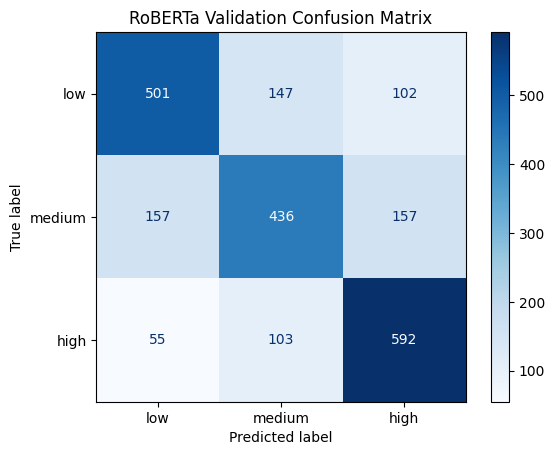


RoBERTa - Test Results
              precision    recall  f1-score   support

         low      0.673     0.671     0.672       750
      medium      0.597     0.524     0.558       750
        high      0.692     0.780     0.734       750

    accuracy                          0.658      2250
   macro avg      0.654     0.658     0.655      2250
weighted avg      0.654     0.658     0.655      2250



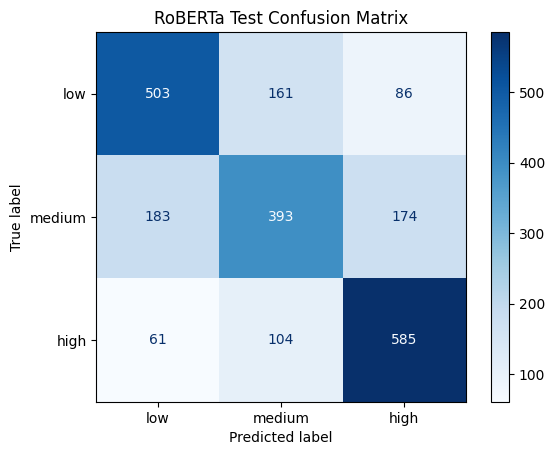

In [24]:
# Phase 3: RoBERTa Model (70/15/15 Split)

!pip -q install transformers datasets accelerate evaluate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import evaluate

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)


RANDOM_STATE = 42
SAMPLE_PER_CLASS = 5000
MODEL_CHECKPOINT = "roberta-base"
MAX_LENGTH = 256

# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Device:", device)
# if device == "cuda":
#     print("GPU:", torch.cuda.get_device_name(0))


# 1. Load + subsample
df = pd.read_csv("rmhd_2020_processed_balanced.csv")

sampled_parts = []
for label, group in df.groupby("label"):
    sampled_parts.append(group.sample(n=SAMPLE_PER_CLASS, random_state=RANDOM_STATE))

sample_df = (
    pd.concat(sampled_parts)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f"\nWorking sample: {len(sample_df)} rows")
print(sample_df["label"].value_counts())


# 2. Label mapping
label2id = {"low": 0, "medium": 1, "high": 2}
id2label = {0: "low", 1: "medium", 2: "high"}

sample_df["label_id"] = sample_df["label"].map(label2id)


# 3. Train / Val / Test Split (70/15/15)
X = sample_df["text"]
y = sample_df["label_id"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


# 4. Convert to Hugging Face dataset
train_df = pd.DataFrame({"text": X_train.tolist(), "label": y_train.tolist()})
val_df   = pd.DataFrame({"text": X_val.tolist(),   "label": y_val.tolist()})
test_df  = pd.DataFrame({"text": X_test.tolist(),  "label": y_test.tolist()})

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})


# 5. Tokenization
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# 6. Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)
    f1_macro = f1_metric.compute(predictions=preds, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "f1_macro": f1_macro["f1"]
    }


# 7. Load model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


# 8. Training arguments
training_args = TrainingArguments(
    output_dir="./roberta_rmhd_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)


# 9. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


# 10. Train
print("\nRoBERTa training")
trainer.train()


# 11. Validation Evaluation
val_outputs = trainer.predict(tokenized_dataset["validation"])
val_logits = val_outputs.predictions
val_preds = np.argmax(val_logits, axis=-1)
val_labels = np.array(tokenized_dataset["validation"]["label"])

print(f"\n{'─'*50}")
print("RoBERTa — Validation Results")
print('─'*50)
print(classification_report(
    val_labels,
    val_preds,
    target_names=["low", "medium", "high"],
    digits=3
))


# 12. Validation Confusion Matrix
cm_val = confusion_matrix(val_labels, val_preds, labels=[0, 1, 2])
disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["low", "medium", "high"]
)

disp_val.plot(cmap="Blues")
plt.title("RoBERTa Validation Confusion Matrix")
plt.show()


# 13. Test Evaluation
test_outputs = trainer.predict(tokenized_dataset["test"])
test_logits = test_outputs.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_labels = np.array(tokenized_dataset["test"]["label"])

print(f"\n{'='*50}")
print("RoBERTa - Test Results")
print('='*50)
print(classification_report(
    test_labels,
    test_preds,
    target_names=["low", "medium", "high"],
    digits=3
))


# 14. Test Confusion Matrix
cm_test = confusion_matrix(test_labels, test_preds, labels=[0, 1, 2])
disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["low", "medium", "high"]
)

disp_test.plot(cmap="Blues")
plt.title("RoBERTa Test Confusion Matrix")
plt.show()

## Phase 4.1: Linguistic Analysis
- Using TF-IDF + Logistc regression to find out the most predictive features for each class.
- Error analysis

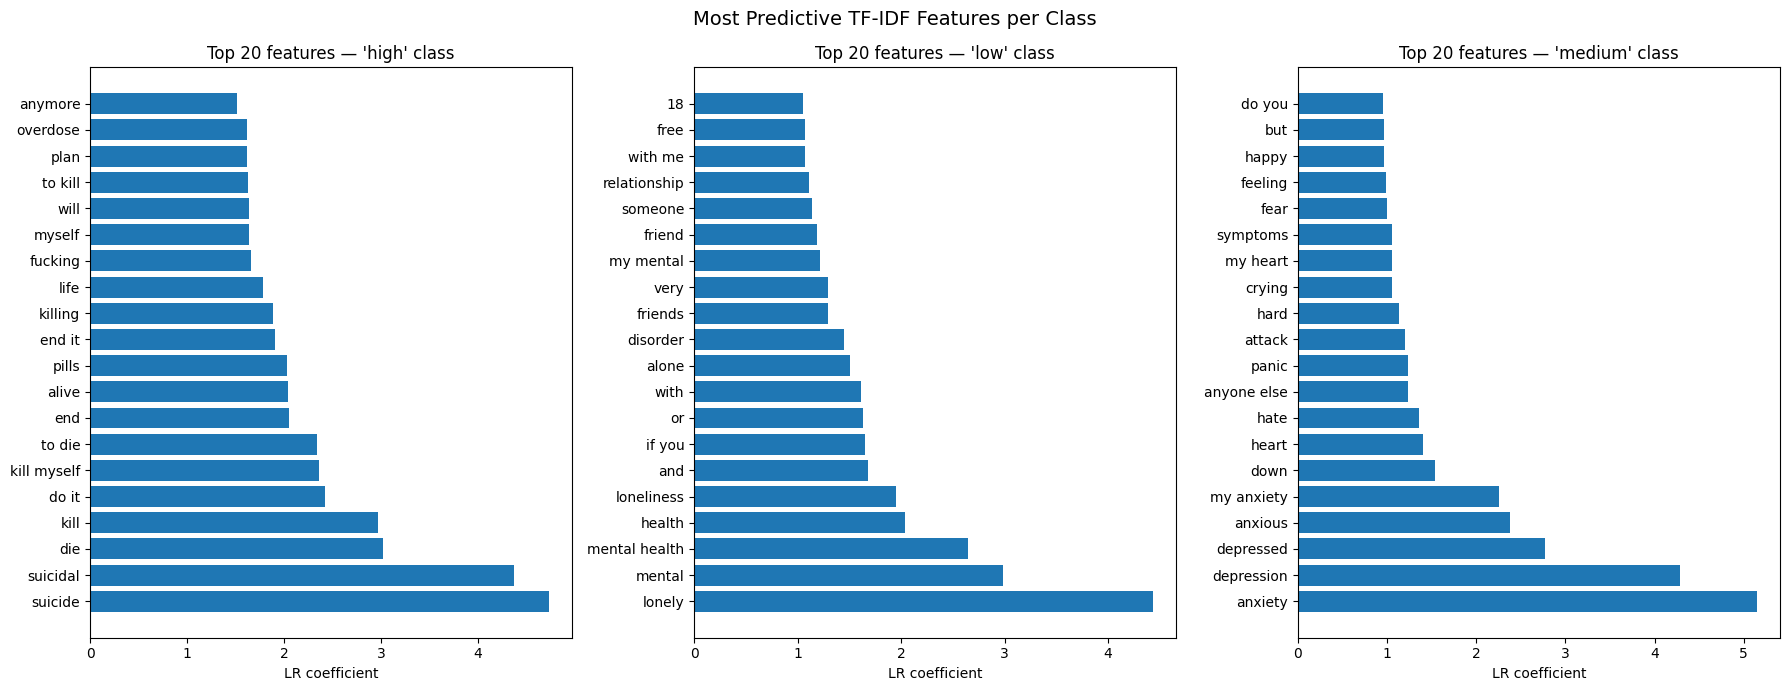


=== Logistic Regression Error Analysis ===
Total misclassified: 804 / 2250

Misclassification breakdown:
  true predicted  count  pct
  high       low    106 13.2
  high    medium    127 15.8
   low      high     85 10.6
   low    medium    151 18.8
medium      high    133 16.5
medium       low    202 25.1


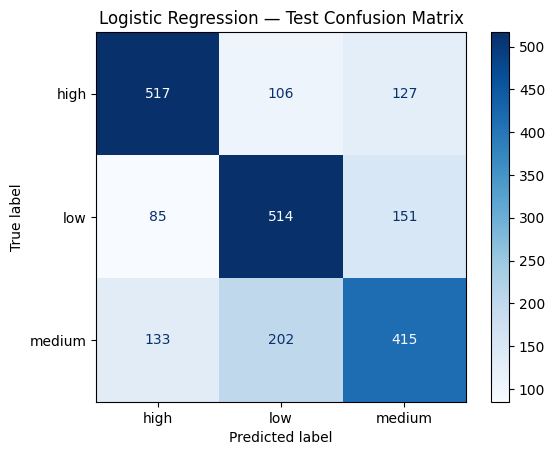


=== Per-class Error Rate (LR) ===
high    : 31.1% error rate
low     : 31.5% error rate
medium  : 44.7% error rate


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

lr_model = models["Logistic Regression"]

# 1. Top TF-IDF Features per Class (LR coefficients)
feature_names = np.array(tfidf.get_feature_names_out())
class_labels = list(lr_model.classes_)
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, (label, ax) in enumerate(zip(class_labels, axes)):
    coefs = lr_model.coef_[i]
    top_idx = np.argsort(coefs)[-TOP_N:][::-1]

    top_features = feature_names[top_idx]
    top_scores = coefs[top_idx]

    ax.barh(range(TOP_N), top_scores[::-1])
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_features[::-1], fontsize=10)
    ax.set_title(f"Top {TOP_N} features — '{label}' class")
    ax.set_xlabel("LR coefficient")
    ax.invert_yaxis()

plt.suptitle("Most Predictive TF-IDF Features per Class", fontsize=14)
plt.tight_layout()
plt.show()


# 2. Error Analysis (Logistic Regression)
test_df_lr = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true": y_test.reset_index(drop=True),
    "predicted": pd.Series(lr_model.predict(X_test_vec)).reset_index(drop=True)
})

errors_lr = test_df_lr[test_df_lr["true"] != test_df_lr["predicted"]].copy()

print("\n=== Logistic Regression Error Analysis ===")
print(f"Total misclassified: {len(errors_lr)} / {len(test_df_lr)}")

print("\nMisclassification breakdown:")
error_counts = (
    errors_lr.groupby(["true", "predicted"])
    .size()
    .reset_index(name="count")
)
error_counts["pct"] = (error_counts["count"] / len(errors_lr) * 100).round(1)
print(error_counts.to_string(index=False))


# 3. Confusion Matrix
labels_order = list(lr_model.classes_)
cm = confusion_matrix(test_df_lr["true"], test_df_lr["predicted"], labels=labels_order)

disp = ConfusionMatrixDisplay(cm, display_labels=labels_order)
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Test Confusion Matrix")
plt.show()


# 4. Per-class Error Rate
print("\n=== Per-class Error Rate (LR) ===")
for label in labels_order:
    subset = test_df_lr[test_df_lr["true"] == label]
    error_rate = (subset["true"] != subset["predicted"]).mean()
    print(f"{label:<8}: {error_rate:.1%} error rate")

## Phase 4.2: Misclassification Analysis

- Find misclasscification rate per class
- Give some samples

In [32]:
import pandas as pd

# Get labels directly from tokenized dataset (correct order)
true_ids = np.array(tokenized_dataset["test"]["label"])
pred_ids = np.argmax(test_outputs.predictions, axis=-1)

# Get texts from the SAME dataset order
texts = dataset["test"]["text"]

id2label = {0: "low", 1: "medium", 2: "high"}

roberta_df = pd.DataFrame({
    "text": texts,
    "true": [id2label[i] for i in true_ids],
    "predicted": [id2label[i] for i in pred_ids]
})

roberta_df["correct"] = roberta_df["true"] == roberta_df["predicted"]


# 1. Overall errors
errors = roberta_df[~roberta_df["correct"]]

print("\n=== RoBERTa Error Analysis ===")
print(f"Total misclassified: {len(errors)} / {len(roberta_df)}")


# 2. Misclassification breakdown
print("\nMisclassification breakdown:")
breakdown = (
    errors.groupby(["true", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print(breakdown.to_string(index=False))


# 3. Per-class error rate
print("\n=== Per-class Error Rate ===")
for label in ["low", "medium", "high"]:
    subset = roberta_df[roberta_df["true"] == label]
    error_rate = (subset["true"] != subset["predicted"]).mean()
    print(f"{label:<8}: {error_rate:.1%} error rate")


# 4. Sample errors
print("\n=== Sample Misclassified Examples ===")

for _, row in errors.sample(5, random_state=42).iterrows():
    print("\n" + "="*60)
    print(f"TRUE: {row['true']} | PRED: {row['predicted']}")
    print("-"*60)
    print(row["text"][:400].replace("\n", " "))


=== RoBERTa Error Analysis ===
Total misclassified: 769 / 2250

Misclassification breakdown:
  true predicted  count
medium       low    183
medium      high    174
   low    medium    161
  high    medium    104
   low      high     86
  high       low     61

=== Per-class Error Rate ===
low     : 32.9% error rate
medium  : 47.6% error rate
high    : 22.0% error rate

=== Sample Misclassified Examples ===

TRUE: low | PRED: high
------------------------------------------------------------
don’t know if i have the right to post here but here it goes i’m in middle school now normally that wouldn’t be so bad other than the fact that i’m 6,3 weigh over 270 pounds and am made of mostly muscle i look unapproachable and it caused me to have basically no friends because everyone is either scared of me or they just completely avoid me the only friends i have i almost never talk to and i hav

TRUE: medium | PRED: low
------------------------------------------------------------
just posting he